Dimensi Data (Shape): (300, 4)

Ringkasan Statistik Deskriptif:
       pengalaman     edu    gaji
count      300.00  300.00  300.00
mean         9.90    0.89   27.40
std          5.89    0.83   13.41
min          0.10    0.00    1.67
25%          4.78    0.00   16.24
50%         10.23    1.00   27.97
75%         15.14    2.00   38.89
max         19.80    2.00   54.22


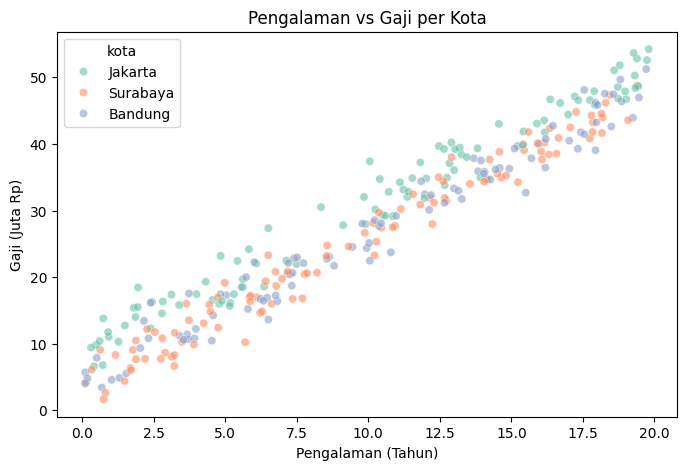

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
n = 300

pengalaman = np.random.uniform(0, 20, n)
edu = np.random.choice([0, 1, 2], n)
kota = np.random.choice(['Jakarta','Surabaya','Bandung'], n)
gaji = (3.0 + 2.2*pengalaman + 1.5*edu
        + np.where(kota=='Jakarta', 4.0, 0)
        + np.random.normal(0, 2, n))

#menggabungkan ke bentuk DataFrame Pandas
df = pd.DataFrame({
    'pengalaman': pengalaman,
    'edu': edu,
    'kota': kota,
    'gaji': gaji
})

print('Dimensi Data (Shape):', df.shape)
print('\nRingkasan Statistik Deskriptif:')
print(df.describe().round(2))

#visualisasi Scatter Plot (Pengalaman vs Gaji per Kota)
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='pengalaman', y='gaji', hue='kota', palette='Set2', alpha=0.6)
plt.title('Pengalaman vs Gaji per Kota')
plt.xlabel('Pengalaman (Tahun)')
plt.ylabel('Gaji (Juta Rp)')
plt.show()

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df = pd.get_dummies(df, columns=['kota'], drop_first=True, dtype=int)
print('Kolom dataset setelah dilakukan encoding:')
print(df.columns.tolist())

#memisahkan fitur (X) dan target (gaji sebagai y)
X = df.drop('gaji', axis=1)
y = df['gaji']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)
print(f'\nHasil pembagian data -> Train: {X_train.shape[0]} baris, Test: {X_test.shape[0]} baris')

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

Kolom dataset setelah dilakukan encoding:
['pengalaman', 'edu', 'gaji', 'kota_Jakarta', 'kota_Surabaya']

Hasil pembagian data -> Train: 240 baris, Test: 60 baris


In [27]:
from sklearn.linear_model import LinearRegression

#membuat objek model Regresi Linear
model = LinearRegression()

#melatih model menggunakan data training terstandardisasi
model.fit(X_train_s, y_train)

#menampilkan nilai Intercept (Beta Nol)
print(f'β₀ (intercept): {model.intercept_:.3f}')
print()

#membuat DataFrame untuk menampilkan dan mengurutkan koefisien fitur
coef_df = pd.DataFrame({
    'Fitur' : X.columns,
    'Koefisien' : model.coef_.round(3)
}).sort_values('Koefisien', ascending=False)

print("=== Pengaruh Fitur Terhadap Gaji ===")
print(coef_df.to_string(index=False))

β₀ (intercept): 27.514

=== Pengaruh Fitur Terhadap Gaji ===
        Fitur  Koefisien
   pengalaman     13.042
 kota_Jakarta      1.837
          edu      1.188
kota_Surabaya     -0.292


In [29]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

#melakukan prediksi pada data test terstandardisasi
y_pred = model.predict(X_test_s)

#menghitung metrik evaluasi (Menggunakan np.sqrt untuk mencari RMSE)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print('=== Metrik Evaluasi ===')
print(f'MAE               = {mae:.3f} juta rupiah')
print(f'RMSE              = {rmse:.3f} juta rupiah')
print(f'R² (R-Squared)    = {r2:.4f} ({r2*100:.1f}% variasi dijelaskan)')
print(f'Selisih RMSE-MAE  = {rmse-mae:.3f}')

=== Metrik Evaluasi ===
MAE               = 1.649 juta rupiah
RMSE              = 2.123 juta rupiah
R² (R-Squared)    = 0.9740 (97.4% variasi dijelaskan)
Selisih RMSE-MAE  = 0.474


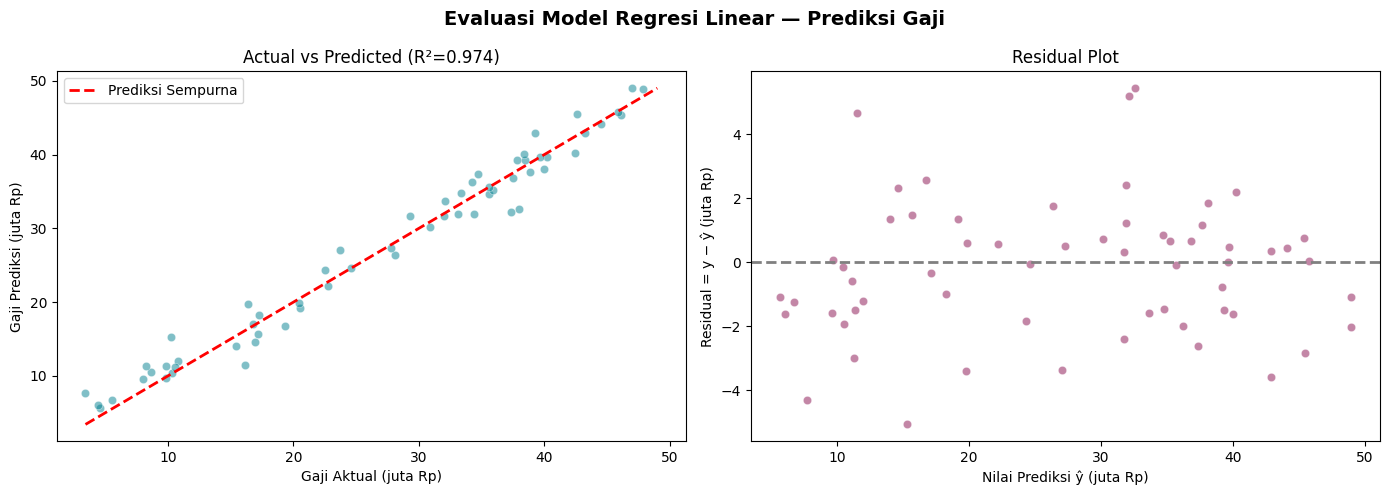

In [30]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, y_pred, alpha=0.5, color='#028090', edgecolors='white', lw=0.5)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(lims, lims, 'r--', lw=2, label='Prediksi Sempurna')
axes[0].set_xlabel('Gaji Aktual (juta Rp)')
axes[0].set_ylabel('Gaji Prediksi (juta Rp)')
axes[0].set_title(f'Actual vs Predicted (R²={r2:.3f})')
axes[0].legend()

residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.5, color='#880E4F', edgecolors='white', lw=0.5)
axes[1].axhline(0, color='gray', linestyle='--', lw=2)
axes[1].set_xlabel('Nilai Prediksi ŷ (juta Rp)')
axes[1].set_ylabel('Residual = y − ŷ (juta Rp)')
axes[1].set_title('Residual Plot')

plt.suptitle('Evaluasi Model Regresi Linear — Prediksi Gaji', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('evaluasi_regresi.png', dpi=150, bbox_inches='tight')
plt.show()